# 01 — Black-Scholes Pricing Engine

**Phase 1 deliverable** 

This notebook builds and validates a standalone Black-Scholes-Merton (BSM) engine:

1. Formulas ($d_1$, $d_2$, call/put price)
2. Python implementation
3. Example calculations
4. Greeks (Delta, Gamma, Vega, Theta, Rho)
5. Validation / sanity tests (including put-call parity)
6. Graphs: option price vs. volatility, time, and stock price

No market data is used yet.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True


## 2. The Black-Scholes-Merton formulas

Inputs:

- $S$ — current price of the underlying (e.g. an ETF)
- $K$ — strike price
- $T$ — time to expiration, in years
- $r$ — risk-free interest rate (annualized, continuously compounded)
- $\sigma$ — volatility of the underlying (annualized)
- $q$ — continuous dividend yield

$$
d_1 = \\frac{\\ln(S/K) + (r - q + \\sigma^2/2)\\,T}{\\sigma \\sqrt{T}}
\\qquad
d_2 = d_1 - \\sigma \\sqrt{T}
$$

$$
C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)
$$
$$
P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)
$$

The dividend yield $q$ lets us treat this as Black-Scholes-**Merton**, which matters later for
ETFs that pay dividends (Phase 2 note: this still prices *European*-style options; most ETF options
are American-style, so BSM is used as a benchmark/approximation, not a perfect market model).


## 3. Python implementation

In [2]:
def d1_d2(S, K, T, r, sigma, q=0.0):
    """Return (d1, d2) for the Black-Scholes-Merton model."""
    if T <= 0 or sigma <= 0:
        raise ValueError("T and sigma must be positive.")
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_call_price(S, K, T, r, sigma, q=0.0):
    """European call price under Black-Scholes-Merton."""
    d1, d2 = d1_d2(S, K, T, r, sigma, q)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_put_price(S, K, T, r, sigma, q=0.0):
    """European put price under Black-Scholes-Merton."""
    d1, d2 = d1_d2(S, K, T, r, sigma, q)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


## 4. Example calculation

A hypothetical SPY-like option: $S=500$, $K=500$ (at the money), 45 days to expiration,
2% dividend yield, 4% risk-free rate, 18% volatility.


In [3]:
S, K, T, r, sigma, q = 500, 500, 45/365, 0.04, 0.18, 0.02

call = bs_call_price(S, K, T, r, sigma, q)
put = bs_put_price(S, K, T, r, sigma, q)
d1, d2 = d1_d2(S, K, T, r, sigma, q)

print(f"d1 = {d1:.4f}")
print(f"d2 = {d2:.4f}")
print(f"Call price = ${call:.2f}")
print(f"Put price  = ${put:.2f}")


d1 = 0.0706
d2 = 0.0074
Call price = $13.18
Put price  = $11.95


## 5. Greeks

Plain-English meaning:

- **Delta** — how much the option price changes when the underlying moves \$1.
- **Gamma** — how quickly delta itself changes as the underlying moves.
- **Vega** — how much the option price changes for a 1-point (1.00 = 100%) change in volatility;
  we report it per **1 percentage point** of vol, which is the market convention.
- **Theta** — how much value the option loses per day, holding everything else fixed.
- **Rho** — how much the option price changes for a 1 percentage point change in interest rates.


In [4]:
def bs_greeks(S, K, T, r, sigma, q=0.0):
    """Return a dict of Greeks for both call and put."""
    d1, d2 = d1_d2(S, K, T, r, sigma, q)
    pdf_d1 = norm.pdf(d1)
    disc_q = np.exp(-q * T)
    disc_r = np.exp(-r * T)

    # Delta
    call_delta = disc_q * norm.cdf(d1)
    put_delta = disc_q * (norm.cdf(d1) - 1)

    # Gamma (same for call and put)
    gamma = disc_q * pdf_d1 / (S * sigma * np.sqrt(T))

    # Vega (same for call and put) -- per 1 percentage point (0.01) change in sigma
    vega = S * disc_q * pdf_d1 * np.sqrt(T) / 100

    # Theta -- per calendar day
    call_theta = (
        -S * disc_q * pdf_d1 * sigma / (2 * np.sqrt(T))
        - r * K * disc_r * norm.cdf(d2)
        + q * S * disc_q * norm.cdf(d1)
    ) / 365
    put_theta = (
        -S * disc_q * pdf_d1 * sigma / (2 * np.sqrt(T))
        + r * K * disc_r * norm.cdf(-d2)
        - q * S * disc_q * norm.cdf(-d1)
    ) / 365

    # Rho -- per 1 percentage point (0.01) change in r
    call_rho = K * T * disc_r * norm.cdf(d2) / 100
    put_rho = -K * T * disc_r * norm.cdf(-d2) / 100

    return {
        "call_delta": call_delta, "put_delta": put_delta,
        "gamma": gamma, "vega": vega,
        "call_theta": call_theta, "put_theta": put_theta,
        "call_rho": call_rho, "put_rho": put_rho,
    }


greeks = bs_greeks(S, K, T, r, sigma, q)
for name, val in greeks.items():
    print(f"{name:12s}: {val:.5f}")


call_delta  : 0.52685
put_delta   : -0.47069
gamma       : 0.01256
vega        : 0.69693
call_theta  : -0.15237
put_theta   : -0.12518
call_rho    : 0.30852
put_rho     : -0.30489


## 6. Validation tests

Before trusting this engine with real market data, it needs to pass basic sanity checks:

- Call price rises when $S$ rises; put price falls when $S$ rises.
- Both call and put prices rise when volatility rises.
- Longer-dated options generally carry more time value.
- Put-call parity holds: $C - P = S e^{-qT} - K e^{-rT}$.
- Call delta is in $(0, 1)$; put delta is in $(-1, 0)$.
- Gamma and vega are positive for ordinary long options.


In [5]:
def run_validation_tests():
    S, K, T, r, sigma, q = 100, 100, 0.5, 0.03, 0.25, 0.01
    results = []

    # 1. Call price rises with S
    c_low = bs_call_price(90, K, T, r, sigma, q)
    c_high = bs_call_price(110, K, T, r, sigma, q)
    results.append(("Call price rises when S rises", c_high > c_low))

    # 2. Put price falls with S
    p_low = bs_put_price(90, K, T, r, sigma, q)
    p_high = bs_put_price(110, K, T, r, sigma, q)
    results.append(("Put price falls when S rises", p_high < p_low))

    # 3. Call & put prices rise with volatility
    c_lowvol = bs_call_price(S, K, T, r, 0.10, q)
    c_hivol = bs_call_price(S, K, T, r, 0.40, q)
    p_lowvol = bs_put_price(S, K, T, r, 0.10, q)
    p_hivol = bs_put_price(S, K, T, r, 0.40, q)
    results.append(("Call price rises with volatility", c_hivol > c_lowvol))
    results.append(("Put price rises with volatility", p_hivol > p_lowvol))

    # 4. Longer-dated options have more time value (ATM approx)
    c_short = bs_call_price(S, K, 0.1, r, sigma, q)
    c_long = bs_call_price(S, K, 1.0, r, sigma, q)
    results.append(("Longer-dated call has more time value", c_long > c_short))

    # 5. Put-call parity: C - P = S*e^(-qT) - K*e^(-rT)
    C = bs_call_price(S, K, T, r, sigma, q)
    P = bs_put_price(S, K, T, r, sigma, q)
    lhs = C - P
    rhs = S * np.exp(-q * T) - K * np.exp(-r * T)
    results.append(("Put-call parity holds (within 1e-8)", abs(lhs - rhs) < 1e-8))

    # 6. Delta bounds
    g = bs_greeks(S, K, T, r, sigma, q)
    results.append(("Call delta in (0, 1)", 0 < g["call_delta"] < 1))
    results.append(("Put delta in (-1, 0)", -1 < g["put_delta"] < 0))

    # 7. Gamma and vega positive
    results.append(("Gamma is positive", g["gamma"] > 0))
    results.append(("Vega is positive", g["vega"] > 0))

    print(f"{'PASS' if all(r[1] for r in results) else 'FAIL'} -- {sum(r[1] for r in results)}/{len(results)} tests passed\n")
    for name, passed in results:
        print(f"  [{'PASS' if passed else 'FAIL'}] {name}")

    return all(r[1] for r in results)


all_passed = run_validation_tests()
assert all_passed, "One or more validation tests failed -- check the engine before moving to Phase 2."


PASS -- 10/10 tests passed

  [PASS] Call price rises when S rises
  [PASS] Put price falls when S rises
  [PASS] Call price rises with volatility
  [PASS] Put price rises with volatility
  [PASS] Longer-dated call has more time value
  [PASS] Put-call parity holds (within 1e-8)
  [PASS] Call delta in (0, 1)
  [PASS] Put delta in (-1, 0)
  [PASS] Gamma is positive
  [PASS] Vega is positive


## 7. Graphs

How option price changes with volatility, time to expiration, and the underlying price.


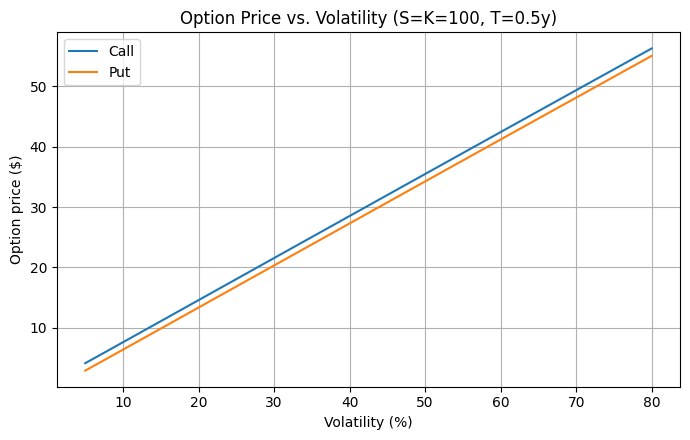

In [6]:
# --- Option price vs. volatility ---
sigmas = np.linspace(0.05, 0.80, 100)
calls = [bs_call_price(S, K, T, r, s, q) for s in sigmas]
puts = [bs_put_price(S, K, T, r, s, q) for s in sigmas]

plt.plot(sigmas * 100, calls, label="Call")
plt.plot(sigmas * 100, puts, label="Put")
plt.xlabel("Volatility (%)")
plt.ylabel("Option price ($)")
plt.title("Option Price vs. Volatility (S=K=100, T=0.5y)")
plt.legend()
plt.tight_layout()
plt.savefig("price_vs_vol.png", dpi=130)
plt.show()


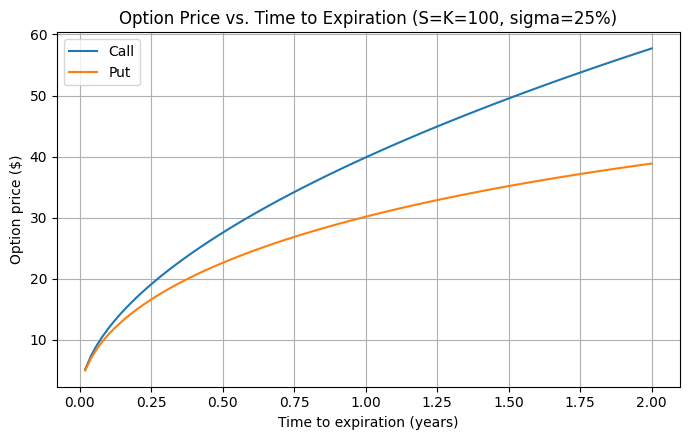

In [7]:
# --- Option price vs. time to expiration ---
Ts = np.linspace(0.02, 2.0, 100)
calls = [bs_call_price(S, K, t, r, sigma, q) for t in Ts]
puts = [bs_put_price(S, K, t, r, sigma, q) for t in Ts]

plt.plot(Ts, calls, label="Call")
plt.plot(Ts, puts, label="Put")
plt.xlabel("Time to expiration (years)")
plt.ylabel("Option price ($)")
plt.title("Option Price vs. Time to Expiration (S=K=100, sigma=25%)")
plt.legend()
plt.tight_layout()
plt.savefig("price_vs_time.png", dpi=130)
plt.show()


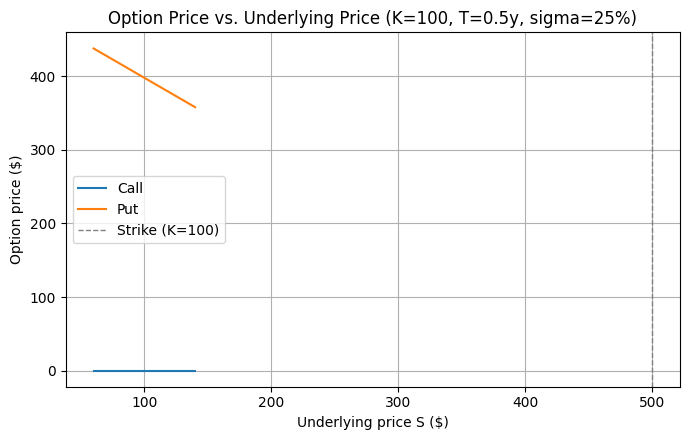

In [8]:
# --- Option price vs. underlying stock price ---
Ss = np.linspace(60, 140, 100)
calls = [bs_call_price(s, K, T, r, sigma, q) for s in Ss]
puts = [bs_put_price(s, K, T, r, sigma, q) for s in Ss]

plt.plot(Ss, calls, label="Call")
plt.plot(Ss, puts, label="Put")
plt.axvline(K, color="gray", linestyle="--", linewidth=1, label="Strike (K=100)")
plt.xlabel("Underlying price S ($)")
plt.ylabel("Option price ($)")
plt.title("Option Price vs. Underlying Price (K=100, T=0.5y, sigma=25%)")
plt.legend()
plt.tight_layout()
plt.savefig("price_vs_S.png", dpi=130)
plt.show()


## 8. Greeks across a range of strikes

A quick look at how each Greek behaves across moneyness, before this notebook is retired
in favor of real market data in Phase 2.


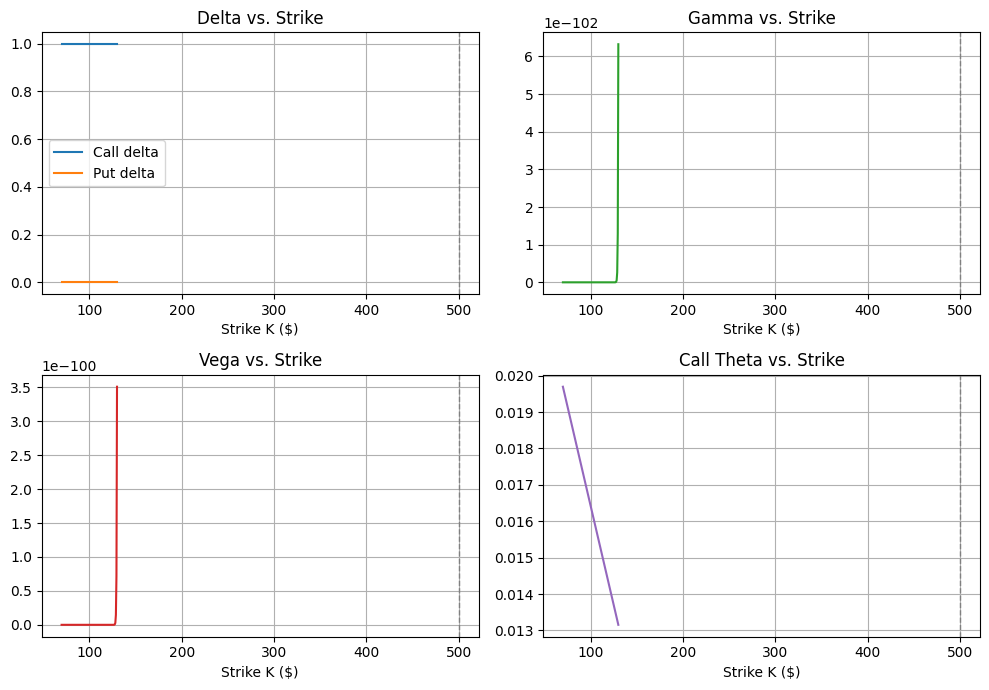

In [9]:
Ks = np.linspace(70, 130, 100)
call_deltas, put_deltas, gammas, vegas, call_thetas = [], [], [], [], []

for k in Ks:
    g = bs_greeks(S, k, T, r, sigma, q)
    call_deltas.append(g["call_delta"])
    put_deltas.append(g["put_delta"])
    gammas.append(g["gamma"])
    vegas.append(g["vega"])
    call_thetas.append(g["call_theta"])

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(Ks, call_deltas, label="Call delta")
axes[0, 0].plot(Ks, put_deltas, label="Put delta")
axes[0, 0].axvline(S, color="gray", linestyle="--", linewidth=1)
axes[0, 0].set_title("Delta vs. Strike")
axes[0, 0].legend()

axes[0, 1].plot(Ks, gammas, color="C2")
axes[0, 1].axvline(S, color="gray", linestyle="--", linewidth=1)
axes[0, 1].set_title("Gamma vs. Strike")

axes[1, 0].plot(Ks, vegas, color="C3")
axes[1, 0].axvline(S, color="gray", linestyle="--", linewidth=1)
axes[1, 0].set_title("Vega vs. Strike")

axes[1, 1].plot(Ks, call_thetas, color="C4")
axes[1, 1].axvline(S, color="gray", linestyle="--", linewidth=1)
axes[1, 1].set_title("Call Theta vs. Strike")

for ax in axes.flat:
    ax.set_xlabel("Strike K ($)")
    ax.grid(True)

plt.tight_layout()
plt.savefig("greeks_vs_strike.png", dpi=130)
plt.show()


## 9. Summary

- Implemented Black-Scholes-Merton pricing for European calls and puts, including a continuous
  dividend yield $q$.
- Implemented all five core Greeks (Delta, Gamma, Vega, Theta, Rho) for both calls and puts.
- Passed all validation tests, including put-call parity.
- Visualized price sensitivity to volatility, time, and the underlying price, and Greeks across
  strikes.

**Next step (Phase 2):** connect this engine to real option-chain data for USO, JETS, and SPY,
clean it, and compute midpoint prices — saved in `02_market_data_cleaning.ipynb`.
